In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
with open("dano_dataset_travel.csv", "r", encoding="utf-8") as f:
    for i in range(2):
        print(f.readline())

order_online_payment_flg;account_rk;client_rk;order_rk;loyalty_program_type_nm;bundle_nm;order_type_cd;order_status_cd;party_first_order_dt;party_first_order_type_dt;free_cancel_booking_dttm;created_dttm;cancel_dttm;book_start_dttm;local_book_start_dttm;book_end_dttm;hotel_country;hotel_city;avia_dep_city;avia_arr_city;promo_code_discount_amt;loyalty_accrual_rub_amt;nominal_price_eur_amt;nominal_price_rub_amt;order_item_cnt;month_beginning_balance_rub;monthly_income_amt;suppress_email_flg;suppress_call_flg;bounce_cd;last_sms_success_flg;call_contact_6m_flg;call_contact_3m_flg;call_contact_1m_flg;good_email_address_flg;bad_email_address_flg;email_valid_flg;children_cnt;age;age_type_cd;parent_meeting_region_nm;delivery_region_category_cd;lvn_city_nm;lvn_state_nm;time_zone_delta_tm;time_zone_cd;last_used_product_cd;first_used_product_cd;mobile_phone_operator_nm;marital_status_cd;education_level_cd;birth_place;gender_cd;last_sms_dt;last_email_send_dt;last_session_dttm

1,0;209c833731e84d21

**Разделитель - ;**

In [3]:
df = pd.read_csv("dano_dataset_travel.csv", sep=';')

C:\Users\Petr\AppData\Local\Temp\ipykernel_27128\1195759353.py:1: DtypeWarning: Columns (31,32,33,45) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("dano_dataset_travel.csv", sep=';')


# Беглый взгляд на данные

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 835938 entries, 0 to 835937
Data columns (total 56 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   order_online_payment_flg     786885 non-null  object 
 1   account_rk                   835938 non-null  object 
 2   client_rk                    835938 non-null  object 
 3   order_rk                     835938 non-null  object 
 4   loyalty_program_type_nm      754957 non-null  object 
 5   bundle_nm                    588049 non-null  object 
 6   order_type_cd                786885 non-null  object 
 7   order_status_cd              779514 non-null  object 
 8   party_first_order_dt         786885 non-null  object 
 9   party_first_order_type_dt    786767 non-null  object 
 10  free_cancel_booking_dttm     75600 non-null   object 
 11  created_dttm                 786885 non-null  object 
 12  cancel_dttm                  0 non-null       float64
 13 

In [5]:
nan_percent = df.isna().mean() * 100
print(nan_percent.sort_values())

suppress_email_flg               0.000000
time_zone_cd                     0.000000
time_zone_delta_tm               0.000000
delivery_region_category_cd      0.000000
email_valid_flg                  0.000000
suppress_call_flg                0.000000
last_session_dttm                0.000000
order_rk                         0.000000
client_rk                        0.000000
account_rk                       0.000000
age                              0.000120
last_used_product_cd             0.000359
age_type_cd                      0.029667
mobile_phone_operator_nm         0.148336
last_sms_success_flg             0.239133
last_sms_dt                      0.239133
first_used_product_cd            0.294280
birth_place                      0.354691
gender_cd                        1.215042
book_start_dttm                  5.868019
order_type_cd                    5.868019
created_dttm                     5.868019
nominal_price_eur_amt            5.868019
nominal_price_rub_amt            5

In [6]:
count_unique = df.nunique().sort_values()
print(len(count_unique))
count_unique

56


cancel_dttm                         0
order_online_payment_flg            1
call_contact_1m_flg                 1
call_contact_3m_flg                 1
call_contact_6m_flg                 1
gender_cd                           2
email_valid_flg                     2
bad_email_address_flg               2
good_email_address_flg              2
last_sms_success_flg                2
suppress_call_flg                   2
suppress_email_flg                  2
order_type_cd                       2
delivery_region_category_cd         3
age_type_cd                         4
last_used_product_cd                4
education_level_cd                  5
marital_status_cd                   6
order_status_cd                     7
children_cnt                        8
bundle_nm                           9
first_used_product_cd               9
order_item_cnt                      9
bounce_cd                          10
time_zone_delta_tm                 12
time_zone_cd                       23
loyalty_prog

In [7]:
df.sample(10).T

,59562,70773,369255,279093,55739,452845,593397,184639,534177,514295
order_online_payment_flg,"1,0","1,0","1,0","1,0","1,0","1,0","1,0","1,0","1,0","1,0"
account_rk,832bff2a58c9ef850f95542804e5667067f273c266ac6b...,98433173ed309f2eec4db607dacc195d3c869dfa322223...,98aaae80d817b567dd429c9796100616c81511894c36cf...,ae0c72e78ad4fb9498d031724dd3a2c26ecc79976ccda7...,06248af7e6d934607fdc4b3fe201ae937f378f9749f631...,f00ad10ad530d002435ffa970d9511385df1624481d6a2...,91eba82c320d46953b0bca262857f294c2cfadc20f6198...,745a5482a7fce7f97a92a230ac73e0ddf991a4a980428d...,f9c5888d7936f764345b3bab3115731540da84682c10ae...,012f39d075eb9550acde1c2890dd21b5dbf2eea72c773b...
client_rk,7c9f35d78b8168456e09338a5b5a101b8df43eac91ec14...,5e060dd30a46676272bcbdcad85a3ab80b39823d387195...,f4a7f8988bae9e610e7015089884af51e61c1654a925b2...,5530478f935f7528bd7d123e764b310099839e72279a12...,38381b77a5f2204f8a273a9e053968192f6e0ccbcd73cb...,e809cde46307e21d1f47a472ec908b46dde3d5caec8e12...,a9979e2b04d43be666b4fff41a86595db1916a1ee83560...,372e2be8e63cf1ddd152c9853e48ec8d44c4a6c1319cfc...,0b6bf667afae8e8f51814f9713ff9f891c6b50389e13f0...,c61c129255473a1c3cd27ec22c6247a70a6234fa545085...
order_rk,3685333fbb0499fb030191389bf7093423f886bd951a22...,2937f15f24adb01956faddf97d55917d5d0a6195986bb1...,29f9bf403adc1e341dbe8a6b0ad75167eb15571ed6db55...,9a6b6831bec8cca096c4786b3aa4b559ab139a5b097aea...,281d2b719854ae2a90fdb81d319bdbfd293d6f4c07b382...,1c61a54674a49566404f55449aeadca1e8225c0eb7340d...,9df07e7c8ae163a137cf0151c1cdaa24a9b3920914ffc6...,3e5822ab180c2ade741c9e737ada10669f6a046658f6ba...,5ec61e958b569a14eeb9f47f1a4ccf9a86d9aa116942eb...,7687712b5d8ceab00f1134bfc3fce34b34fca3a5f90655...
loyalty_program_type_nm,Tinkoff Black,Bravo,Bravo,Tinkoff Black Premium,Tinkoff Black,Bravo,Tinkoff Black,Tinkoff Black Premium,Tinkoff Black,Tinkoff Black Premium
bundle_nm,Pro,NaN,Pro,Premium,Premium,NaN,Pro,Premium,Pro,Premium
order_type_cd,AIR,AIR,AIR,HOT,AIR,AIR,HOT,AIR,AIR,HOT
order_status_cd,SUC,SUC,SUC,SUC,SUC,SUC,SUC,SUC,SUC,SUC
party_first_order_dt,2024-01-23,2023-10-18,2021-01-23,2022-02-18,2020-03-15,2023-12-03,2022-11-13,2022-06-16,2023-03-03,2021-11-16
party_first_order_type_dt,2024-01-23,2023-10-18,2021-01-23,2022-06-27,2020-09-07,2023-12-03,2023-11-04,2022-06-16,2023-03-03,2024-04-17


# Убираем пробельные символы по бокам и заменяем все текстовые аналоги NaN. Также создаём резрвную копию df, чтобы потом не пришлось заново читать её из файла

In [8]:
df_backup_copy = df.copy(deep=True)

In [9]:
df = df_backup_copy.copy(deep=True)

In [10]:
for col in df.columns: 
    df[col] = df[col].map(lambda x: x.strip() if isinstance(x, str) else x)


list_str_nan = ["", " ", "-", "—", "NaN", "nan", "NULL", "None", "N/A"]
df.replace(list_str_nan, pd.NA, inplace=True)

# Приводим данные к нужным типам

 27  suppress_email_flg           835938 non-null  int64  
 28  suppress_call_flg            835938 non-null  int64  
 29  bounce_cd                    39675 non-null   object 
 30  last_sms_success_flg         833939 non-null  object 
 31  call_contact_6m_flg          271 non-null     object 
 32  call_contact_3m_flg          271 non-null     object 
 33  call_contact_1m_flg          271 non-null     object 
 34  good_email_address_flg       19798 non-null   object 
 35  bad_email_address_flg        19798 non-null   object 
 36  email_valid_flg              835938 non-null  int64      

In [11]:
num_cols = ["promo_code_discount_amt", "nominal_price_eur_amt", "loyalty_accrual_rub_amt", "nominal_price_rub_amt", "order_item_cnt", 
            "month_beginning_balance_rub", "monthly_income_amt", "children_cnt", "age", "time_zone_cd"]

for i in num_cols:
    df[i] = df[i].str.replace(",", ".")
    df[i] = pd.to_numeric(df[i], errors="coerce")

In [12]:
date_cols = ["party_first_order_dt", "party_first_order_type_dt", "party_first_order_type_dt", "free_cancel_booking_dttm", "created_dttm",
             "book_start_dttm", "local_book_start_dttm", "book_end_dttm", "last_sms_dt", "last_email_send_dt", "last_session_dttm"]

for i in date_cols:
    df[i] = pd.to_datetime(df[i], errors="coerce")

In [13]:
date_fg = ["order_online_payment_flg", "last_sms_success_flg", "call_contact_6m_flg", "call_contact_3m_flg", "call_contact_1m_flg",
           "good_email_address_flg", "bad_email_address_flg"] # Исключая suppress_email_flg, suppress_call_flg и email_valid_flg (потому что они int)

for i in date_fg:
    df[i] = df[i].str.replace(",", ".")
    df[i] = pd.to_numeric(df[i], errors="coerce").astype("Int64")

# Повторный беглый просмотр данных

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 835938 entries, 0 to 835937
Data columns (total 56 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   order_online_payment_flg     786885 non-null  Int64         
 1   account_rk                   835938 non-null  object        
 2   client_rk                    835938 non-null  object        
 3   order_rk                     835938 non-null  object        
 4   loyalty_program_type_nm      754957 non-null  object        
 5   bundle_nm                    588049 non-null  object        
 6   order_type_cd                786885 non-null  object        
 7   order_status_cd              779514 non-null  object        
 8   party_first_order_dt         786885 non-null  datetime64[ns]
 9   party_first_order_type_dt    786767 non-null  datetime64[ns]
 10  free_cancel_booking_dttm     75600 non-null   datetime64[ns]
 11  created_dttm              

In [15]:
df.sample(10).T

,242127,178068,574061,825858,779864,567104,408337,531066,378005,579999
order_online_payment_flg,1,1,1,1,1,1,1,<NA>,<NA>,1
account_rk,9f1dd2dbcefd78e5e3e8eb076d38341365e77438bc2876...,3bd5a5f5858e482f4ab0c95ab5b0cff7e2f523e2b7e5de...,00b1516316211dae7b7ef4e2b1784c27354e369f5e4412...,ff414fc83f9834d3093e9a50e28a451a9d29bc9e87ec46...,271e2beb405b7ac6a50a7c1748f0820254f90b1ae3be30...,ad0313e808fe14dab7b285d95a8414e3b4c0cb3583fa58...,db124c8c1d4d069e7aca4b7aa2696c76ccf577fe7f2908...,9b2d5b4678781e53038e91ea5324530a03f27dc1d0e5f6...,9b2d5b4678781e53038e91ea5324530a03f27dc1d0e5f6...,3da25904d1ca06ff56ea56dca6bba521aff9ebf589900d...
client_rk,6e76399f8fea843b4f2af7541a1295c6e9ebe711e4ea37...,69c5b9abcc48de2cd6118eb798670383ccc83450c151cc...,30557736711d0fba2baaeaca94cf65b3d26793bc2da474...,f1f99240a88fd5121cba2b62de3d1dff7c48ddebbb1856...,dce3fd66f59e125bbb6cb0524516c6538bc3af4a3ebe33...,f3d5ce6fec461e6d513862fcfd520dff85f78fdd77e58f...,558814916e64329679f8a24a7f36387a21ed4c9d39e703...,48d36c1bd8724cb26eac75a3cd59a0395ec9427a5df43d...,3bff0e3bdce92636ef415659ac4eaff55ad76f40ca1196...,3cb82e64e8330c1761880ecce64b29d8c0ed3083fe4f54...
order_rk,9aa366552953a13e92f04fcdddd5d57d78b156a958affb...,db2fff01c1ec5a85401bb99bb2db09af798b9b0f98525d...,886410acbe5d9a81d0307857349b70dff6da672295e959...,180a56508f5ce6a824176f382d4878d5ab8f4d4342ab02...,4f48121270f5d23dd10a082de3fb9f43fc93702fbb93ab...,3cee6b8a22835d5277f4adb1025504052dd5cd06278234...,bd6b95ac755be8358a3d5542078152f741ea186e57f1f0...,9b2d5b4678781e53038e91ea5324530a03f27dc1d0e5f6...,9b2d5b4678781e53038e91ea5324530a03f27dc1d0e5f6...,0f6aff8525f77e268d030bde49169904f76352e18d65f4...
loyalty_program_type_nm,Bravo,Tinkoff Black,All Airlines Premium Кредитный,Tinkoff Black,Tinkoff Black,Tinkoff Black,All Airlines,NaN,NaN,Tinkoff Black
bundle_nm,Premium,Pro,Premium,NaN,Pro,Pro,NaN,NaN,NaN,NaN
order_type_cd,AIR,AIR,AIR,AIR,AIR,HOT,AIR,NaN,NaN,AIR
order_status_cd,SUC,SUC,SUC,SUC,SUC,SUC,SUC,NaN,NaN,SUC
party_first_order_dt,2021-05-23 00:00:00,2024-03-07 00:00:00,2019-09-19 00:00:00,2023-08-01 00:00:00,2021-02-25 00:00:00,2021-11-08 00:00:00,2021-11-21 00:00:00,NaT,NaT,2023-08-14 00:00:00
party_first_order_type_dt,2021-06-03 00:00:00,2024-06-29 00:00:00,2019-09-19 00:00:00,2023-08-01 00:00:00,2021-02-25 00:00:00,2021-11-08 00:00:00,2023-11-08 00:00:00,NaT,NaT,2023-08-14 00:00:00


# Функция для быстрого просмотра столбца

1) Процент пустых записей: 9.687440934614768
2) Количество пустых записей: 80981
3) Количество уникальных записей: 36
4) Топ уникальных записей для loyalty_program_type_nm
Tinkoff Black                     289081
Tinkoff Black Premium             189005
All Airlines                      143114
NaN                                80981
Bravo                              41428
All Airlines Premium Кредитный     28634
All Airlines Premium               16277
AllAirLinesDebit                   14824
Tinkoff Black Private               6994
Tinkoff Platinum                    6154
Name: count, dtype: int64:
5) Количество типов записей: loyalty_program_type_nm
<class 'str'>      754957
<class 'float'>     80981
Name: count, dtype: int64


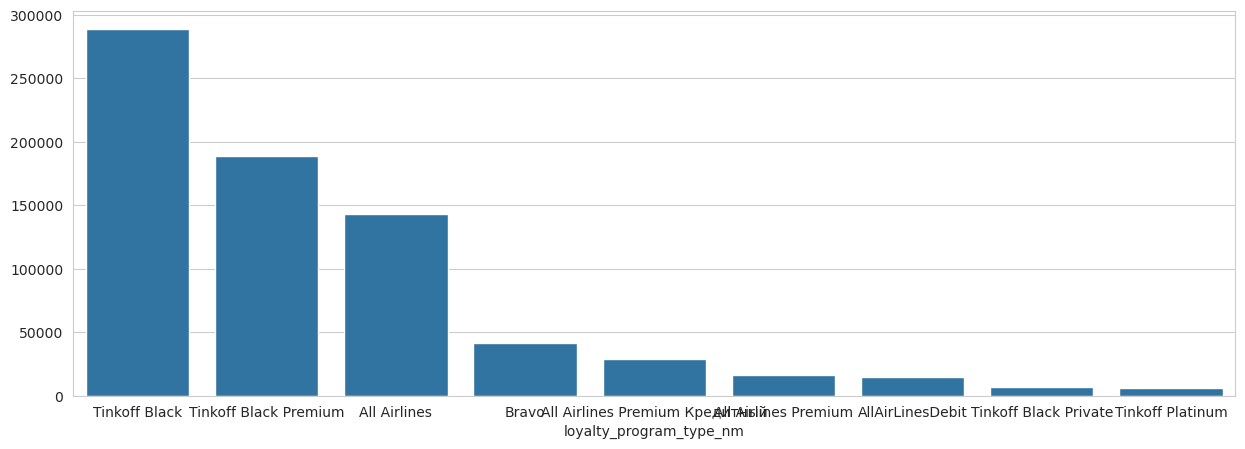

In [16]:
def my_analis(data_set, column, figsize=(10, 5)):
    nan_percent = data_set[column].isna().mean() * 100
    nan_count = data_set[column].isna().sum()
    count_unique = data_set[column].nunique()
    top_values = data_set[column].value_counts(dropna=False, ascending=False).head(count_unique if count_unique <= 10 else 10)
    types = data_set[column].apply(type).value_counts()
    print(f"1) Процент пустых записей: {nan_percent}")
    print(f"2) Количество пустых записей: {nan_count}")
    print(f"3) Количество уникальных записей: {count_unique}")
    print(f"4) Топ уникальных записей для {top_values}:")
    print(f"5) Количество типов записей: {types}")
    with sns.axes_style("whitegrid"):
        plt.figure(figsize=figsize)
        sns.barplot(
            y=top_values.values, 
            x=top_values.index)


my_analis(df, "loyalty_program_type_nm", (15, 5))

# Удаление мало заполненных и других ненужных столбцов. А также доработка данных (bounce_cd).


**Процент незаполненных:**
- children_cnt                    13.905218
- monthly_income_amt              19.482306
- promo_code_discount_amt         26.322287
- order_item_cnt                  26.389637
- avia_dep_city                   26.397053
- avia_arr_city                   26.397053
- bundle_nm                       29.653993
- marital_status_cd               37.688202
- lvn_city_nm                     43.061686
- loyalty_accrual_rub_amt         43.135376
- education_level_cd              43.165163
- book_end_dttm                   79.478382
- hotel_city                      80.590905
- hotel_country                   80.590905
- free_cancel_booking_dttm        90.956267

**Нижнее - УДАЛЯЕМ (много пустых):**
- last_email_send_dt              97.631643
- bad_email_address_flg           97.631643
- good_email_address_flg          97.631643
- call_contact_3m_flg             99.967581
- call_contact_1m_flg             99.967581
- call_contact_6m_flg             99.967581
- cancel_dttm                    100.000000

**Другие столбцы для удаления (эти данные точно не буду сейчас использовать):**
- birth_place - Место рождения
- last_session_dttm - Дата последней сессии
- account_rk - Идентификатор счета
- local_book_start_dttm - Дата заезда в местном часовом поясе (для отелей)
- time_zone_cd - Код часового пояса
- time_zone_delta_tm - Разница часового пояса с Гринвичем

In [17]:
# Мало данных:
cols_to_drop = [
    "last_email_send_dt", "bad_email_address_flg", "good_email_address_flg", "call_contact_3m_flg", "call_contact_1m_flg", 
    "call_contact_6m_flg", "cancel_dttm"]

df2 = df.drop(columns=cols_to_drop)

In [18]:
# Эти данные точно не буду сейчас использовать
cols_to_drop = [
    "birth_place", "last_session_dttm", "account_rk", "local_book_start_dttm", "time_zone_cd", 
    "time_zone_delta_tm"]

df2 = df2.drop(columns=cols_to_drop)

1) Процент пустых записей: 95.25383461452883
2) Количество пустых записей: 796263
3) Количество уникальных записей: 10
4) Топ уникальных записей для bounce_cd
NaN     796263
5,0      25261
15,0      7693
17,0      5403
13,0       400
14,0       366
9,0        257
10,0       192
11,0        62
2,0         25
Name: count, dtype: int64:
5) Количество типов записей: bounce_cd
<class 'float'>    796263
<class 'str'>       39675
Name: count, dtype: int64


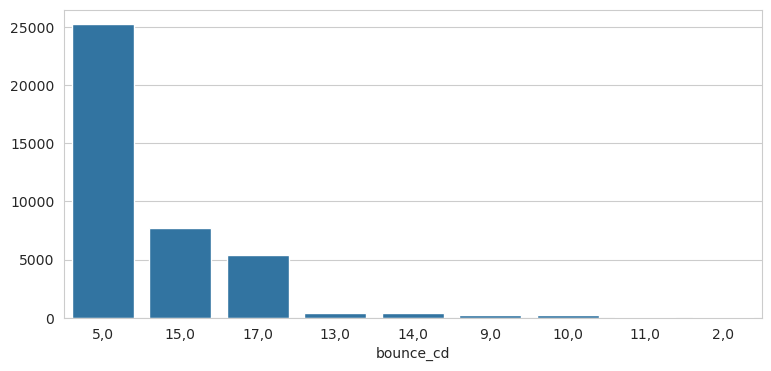

In [19]:
my_analis(df2, "bounce_cd", (9, 4))

bounce_cd - Код smtp-ответа от почтовой системы (отсутствие кода значит успешную отправку, все остальные smtp-коды в открытом доступе)
Тогда заменяем NaN на 1 (доставлено), а остльные занчения на 0 (не доставлено)

# Просмотр общих параметров уже изменённого датасета df2

#### Info()

In [20]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 835938 entries, 0 to 835937
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   order_online_payment_flg     786885 non-null  Int64         
 1   client_rk                    835938 non-null  object        
 2   order_rk                     835938 non-null  object        
 3   loyalty_program_type_nm      754957 non-null  object        
 4   bundle_nm                    588049 non-null  object        
 5   order_type_cd                786885 non-null  object        
 6   order_status_cd              779514 non-null  object        
 7   party_first_order_dt         786885 non-null  datetime64[ns]
 8   party_first_order_type_dt    786767 non-null  datetime64[ns]
 9   free_cancel_booking_dttm     75600 non-null   datetime64[ns]
 10  created_dttm                 786885 non-null  datetime64[ns]
 11  book_start_dttm           

#### Процент незаполненных

In [21]:
df2["bounce_cd"] = df2["bounce_cd"].apply(lambda x: 1 if pd.isna(x) else 0)

In [22]:
nan_percent = df2.isna().mean() * 100
print(nan_percent)

order_online_payment_flg        5.868019
client_rk                       0.000000
order_rk                        0.000000
loyalty_program_type_nm         9.687441
bundle_nm                      29.653993
order_type_cd                   5.868019
order_status_cd                 6.749783
party_first_order_dt            5.868019
party_first_order_type_dt       5.882135
free_cancel_booking_dttm       90.956267
created_dttm                    5.868019
book_start_dttm                 5.868019
book_end_dttm                  79.478382
hotel_country                  80.590905
hotel_city                     80.590905
avia_dep_city                  26.397053
avia_arr_city                  26.397053
promo_code_discount_amt        26.322287
loyalty_accrual_rub_amt        43.135376
nominal_price_eur_amt           5.868019
nominal_price_rub_amt           5.868019
order_item_cnt                 26.389637
month_beginning_balance_rub     7.095024
monthly_income_amt             19.482306
suppress_email_f

#### Количество уникальных значений

In [23]:
count_unique = df2.nunique()
print(len(count_unique))
count_unique

43


order_online_payment_flg            1
client_rk                      148364
order_rk                       786886
loyalty_program_type_nm            36
bundle_nm                           9
order_type_cd                       2
order_status_cd                     7
party_first_order_dt             2500
party_first_order_type_dt        2497
free_cancel_booking_dttm        11325
created_dttm                   786883
book_start_dttm                 99276
book_end_dttm                     558
hotel_country                     133
hotel_city                       3248
avia_dep_city                     532
avia_arr_city                     541
promo_code_discount_amt            88
loyalty_accrual_rub_amt          8726
nominal_price_eur_amt            3154
nominal_price_rub_amt           72052
order_item_cnt                      9
month_beginning_balance_rub    103762
monthly_income_amt               2668
suppress_email_flg                  2
suppress_call_flg                   2
bounce_cd   

# Анализ возможных статусов заказов

1) Процент пустых записей: 6.74978287863454
2) Количество пустых записей: 56424
3) Количество уникальных записей: 7
4) Топ уникальных записей для order_status_cd
SUC    759950
NaN     56424
PRC     18467
ERR       650
NSH       304
CNC        84
REJ        58
Name: count, dtype: int64:
5) Количество типов записей: order_status_cd
<class 'str'>      779514
<class 'float'>     56424
Name: count, dtype: int64


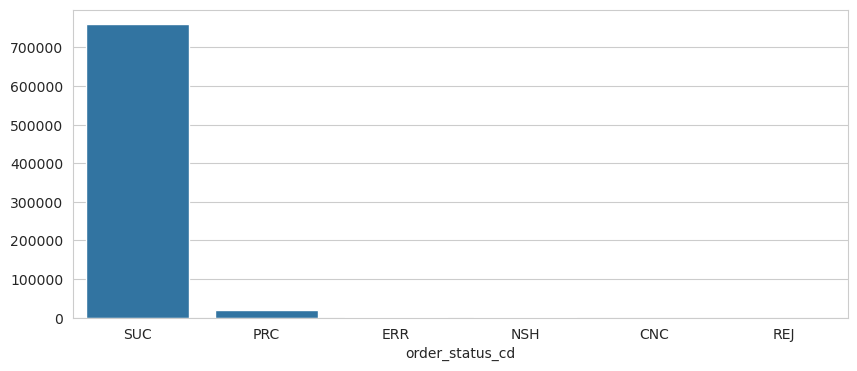

In [24]:
my_analis(df2, "order_status_cd", (10, 4))

Основные три статуса это: SUC, NaN и PRC. Или "успешно", "пусто" и "в процессе" соответственно. Остальные статусы не будем исследовать из-за их незначительности.

# Разделение датасета по типам заказа: отель (HOT), авиабилет (AIR) и без заказа (NaN)

In [25]:
df2['order_type_cd'].unique()

array(['AIR', 'HOT', nan], dtype=object)

In [26]:
df2_HOT = df2[(df2['order_type_cd'] == 'HOT')] 

df2_AIR = df2[(df2['order_type_cd'] == 'AIR')] 

df2_NaN = df2[(df2['order_type_cd'].isna())] 

### Просмотр уникальных статусов заказа для отелей (HOT)

In [27]:
df2_HOT['order_status_cd'].unique()

array(['SUC', nan, 'REJ', 'NSH', 'CNC'], dtype=object)

In [28]:
df2_HOT['order_status_cd'].value_counts()

order_status_cd
SUC    163794
NSH       304
REJ        58
CNC        21
Name: count, dtype: int64

**Статус заказа: Nan**

In [29]:
df2_HOT['order_status_cd'].isna().sum()

7371

In [30]:
df2_HOT[df2_HOT['order_status_cd'].isna()].info()

<class 'pandas.core.frame.DataFrame'>
Index: 7371 entries, 3 to 835875
Data columns (total 43 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   order_online_payment_flg     7371 non-null   Int64         
 1   client_rk                    7371 non-null   object        
 2   order_rk                     7371 non-null   object        
 3   loyalty_program_type_nm      5625 non-null   object        
 4   bundle_nm                    5996 non-null   object        
 5   order_type_cd                7371 non-null   object        
 6   order_status_cd              0 non-null      object        
 7   party_first_order_dt         7371 non-null   datetime64[ns]
 8   party_first_order_type_dt    7312 non-null   datetime64[ns]
 9   free_cancel_booking_dttm     3375 non-null   datetime64[ns]
 10  created_dttm                 7371 non-null   datetime64[ns]
 11  book_start_dttm              7371 non-null   d

**Судя по всему это какие-то неудачные заказы. В них также не указаны отель (страна + город), а также даже количсетво позиций в заказе => УДАЛЯЕМ**

In [31]:
df2_HOT = df2_HOT.dropna(subset=['order_status_cd'])

**Также удаляем строки с другими мало встречающимимся статусами в 'order_status_cd': NSH, REJ, CNC**

In [32]:
df2_HOT = df2_HOT[~df2_HOT['order_status_cd'].isin(['NSH', 'REJ', 'CNC'])]

**Проверка значений**

In [33]:
df2_HOT['order_status_cd'].unique()

array(['SUC'], dtype=object)

In [34]:
df2_HOT['order_status_cd'].value_counts()

order_status_cd
SUC    163794
Name: count, dtype: int64

### Просмотр уникальных статусов заказа для авиабилетов (AIR)

In [35]:
df2_AIR['order_status_cd'].unique()

array(['SUC', 'PRC', 'ERR', 'CNC', 'BRN'], dtype=object)

In [36]:
df2_AIR['order_status_cd'].value_counts()

order_status_cd
SUC    596156
PRC     18467
ERR       650
CNC        63
BRN         1
Name: count, dtype: int64

In [37]:
df2_AIR['order_status_cd'].isna().sum()

0

**Оставляем два самых часто встречающихся статуса: SUC и PRC, то есть "успешно" и "в процессе" соответственно. Остальные - УДАЛЯЕМ. Пустных значений (NaN) - нет**

In [38]:
df2_AIR = df2_AIR[~df2_AIR['order_status_cd'].isin(['ERR', 'CNC', 'BRN'])]

**Проверка значений**

In [39]:
df2_AIR['order_status_cd'].unique()

array(['SUC', 'PRC'], dtype=object)

In [40]:
df2_AIR['order_status_cd'].value_counts()

order_status_cd
SUC    596156
PRC     18467
Name: count, dtype: int64

### Просмотр заказов с невыбранным типом отель (HOT) или авиабилет (AIR),  то есть 'order_type_cd' == NaN

In [41]:
df2_NaN['order_status_cd'].unique()

array([nan], dtype=object)

In [42]:
df2_NaN.shape

(49053, 43)

In [43]:
df2_NaN['client_rk'].nunique()

49053

In [44]:
df2['order_rk'].value_counts(dropna=False, ascending=False).head(10)

order_rk
9b2d5b4678781e53038e91ea5324530a03f27dc1d0e5f6c9bc9d493a23be9de0    49053
fe1c6ce13774d102c655df4c01d54c34d495ef3d4c7e638d5746c1c7adbcc5a0        1
f8ff89531ccbbe2c6a19c68458f73de48dfabdfe3ce10907a7f047658cc0c0df        1
f3b815b9a14cef1fc4ce25ee3543ee5ac18c158fc6edeb98c734b51d755f7226        1
455ba382f9cbc5c691e4d82e0b88694916b112d4d6f46069424637e2364134e3        1
cb60bd2a051f7530c7d6d91184550bf90a0204aaa3e517e7ccf072765bba7fa9        1
dd96b552ae8d655a1e17789f528a1d9673002214f6e3548cfd2dbb1eaa582dfa        1
230e8295629101504cdcf43c33689b18ff08954ed2d5a6b74400f77231316d45        1
707a9fc7f3d1b7561c4104d5a15b6617969afb3cdc60d4a875791f6ff6acbcf4        1
38886291241859cf3005da351b7d7201be789f9e59c81f2d1154ce086161dd72        1
Name: count, dtype: int64

In [45]:
df2_NaN['order_rk'].value_counts()

order_rk
9b2d5b4678781e53038e91ea5324530a03f27dc1d0e5f6c9bc9d493a23be9de0    49053
Name: count, dtype: int64

In [46]:
df2_NaN['client_rk'].nunique()

49053

In [88]:
df2_NaN.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49053 entries, 59 to 835908
Data columns (total 43 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   order_online_payment_flg     0 non-null      Int64         
 1   client_rk                    49053 non-null  object        
 2   order_rk                     49053 non-null  object        
 3   loyalty_program_type_nm      0 non-null      object        
 4   bundle_nm                    0 non-null      object        
 5   order_type_cd                0 non-null      object        
 6   order_status_cd              0 non-null      object        
 7   party_first_order_dt         0 non-null      datetime64[ns]
 8   party_first_order_type_dt    0 non-null      datetime64[ns]
 9   free_cancel_booking_dttm     0 non-null      datetime64[ns]
 10  created_dttm                 0 non-null      datetime64[ns]
 11  book_start_dttm              0 non-null     

**Таким образом, каждой записи из df2_NaN (не HOT и не AIR) соответствует ровно один id клиента без повторов. Также у каждой такой записи один и тот же id заказа. Поэтому будем считать, что все записи в df2_NaN соответствуют клиентам не совершившим ни одного заказа.**

**Количество уникальных клиентов, не совершивших ни одной успешной покупки:**

In [47]:
count_NaN_clients = df2_NaN['client_rk'].nunique()

In [48]:
print(f"Количество уникальных клиентов, не совершивших ни одной успешной покупки: {count_NaN_clients}")

Количество уникальных клиентов, не совершивших ни одной успешной покупки: 49053


# Соотношение успешных (SUC) заказов авиабилетов (AIR) и бронирования отеля (HOT)

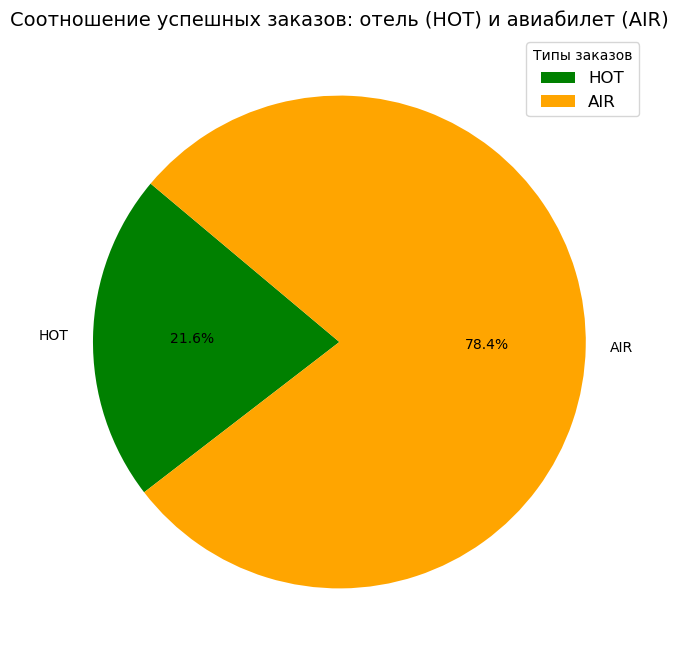

In [49]:
suc_hot_count = df2_HOT[df2_HOT['order_status_cd'] == 'SUC'].shape[0]
suc_air_count = df2_AIR[df2_AIR['order_status_cd'] == 'SUC'].shape[0]

labels = ['HOT', 'AIR']
sizes = [suc_hot_count, suc_air_count]
colors = ['green', 'orange']

plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title('Соотношение успешных заказов: отель (HOT) и авиабилет (AIR)', fontsize=14)

plt.legend(labels, title="Типы заказов", loc="best", fontsize=12)
plt.show()

**Количество бронирований отелей:**

In [50]:
suc_hot_count

163794

**Количество заказов авиабилетов:**

In [51]:
suc_air_count

596156

# Соотношение уникальных клиентов, которые либо только успешно заказывали авиабилеты (AIR Client), либо только успешно бронированли отель (HOT Client), либо успешно совершали обе покупки (HOT + AIR Client). Совместные покупки (HOT + AIR) не обязательно относятся к одной поездке 

**Количество уникальных клиентов, когда-либо совершивших успешную покупку:**

In [52]:
clients_suc = df2[df2['order_status_cd'] == 'SUC'].groupby('client_rk')
count_suc_clients = clients_suc.ngroups

In [53]:
print(f'Количество уникальных клиентов, когда-либо совершивших успешную покупку: {count_suc_clients}')

Количество уникальных клиентов, когда-либо совершивших успешную покупку: 99232


In [54]:
clients_suc_order_type = clients_suc['order_type_cd'].unique().apply(lambda x:  'HOT + AIR' if len(x) == 2 else x[0])
clients_suc_order_type

client_rk
000047e2e70a562001b2b9230bc95c7efcb1103b32717107ada2e90cce3d22b0          AIR
00019ea581c09c72f249b6714222e8931e30448f7ed2eb3358165b41415e708d          AIR
0001d4e275c931cb346856169aa616a8dd14c04de1d21dd82a3f46c2fa146bc2          AIR
00023bb2f46b332c4a84cf3391a6be24b05cedad6f48979f1dd0f65f7b90b406          HOT
00025fad046ff0ce2c86eb2fe19641c56f13034e9224203a18796004547a8b73          HOT
                                                                      ...    
fffd7372b65bbb5aad8538f0e4d11288543caf7598f73745902cbe45cf39d889          AIR
fffdc43175ca31b6890bddfbc948d95f959f6b62b43fa2e08ad15a865b16a6aa          AIR
fffdd44ec229e89655575bf56a9aabb56ea013872c5bb0e5f73f9ce4e95e775a          AIR
fffe80964b7e587ee2c26601a9a80261d1583db7c514fcbffdab40a668a7804d    HOT + AIR
ffff72b45a2425899261e12f738a12cd31fa70e28548e965769f9cb53fbdfcfe          AIR
Name: order_type_cd, Length: 99232, dtype: object

In [55]:
clients_suc_order_type.unique()

array(['AIR', 'HOT', 'HOT + AIR'], dtype=object)

In [56]:
clients_suc_order_type = clients_suc_order_type.value_counts()

In [57]:
clients_suc_order_type

order_type_cd
AIR          52539
HOT + AIR    34141
HOT          12552
Name: count, dtype: int64

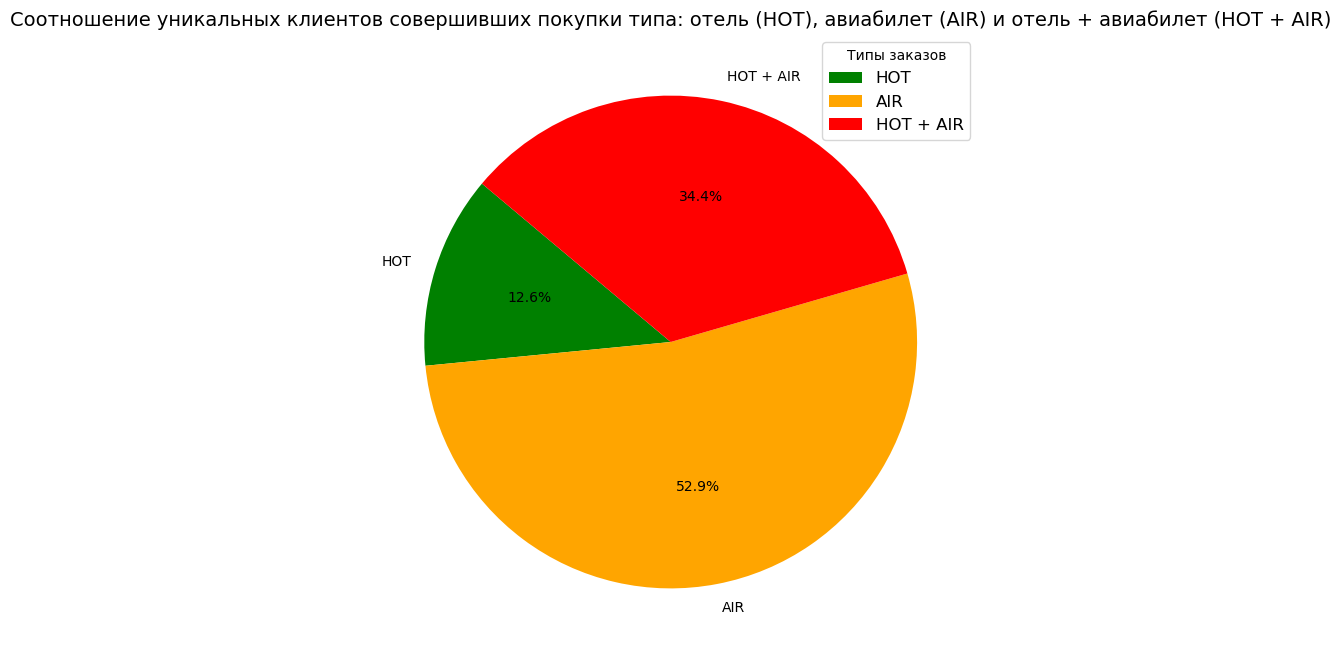

In [58]:
labels = ['HOT', 'AIR', 'HOT + AIR']
sizes = [clients_suc_order_type[labels[0]], clients_suc_order_type[labels[1]], clients_suc_order_type[labels[2]]]
colors = ['green', 'orange', 'red']

plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title('Соотношение уникальных клиентов совершивших покупки типа: отель (HOT), авиабилет (AIR) и отель + авиабилет (HOT + AIR)', fontsize=14)

plt.legend(labels, title="Типы заказов", loc="best", fontsize=12)
plt.show()

**Таким образом, большинство клиентов покупает что-то одно: либо авиабилеты (преимущественно), либо бронирует отел. И только 34% людей когда либо покупали и номер в отеле и авиабилеты.**

# Уникальные клиенты 4 типов: совершившие одну из покупок (отель (HOT), авиабилет (AIR) и отель + авиабилет (HOT + AIR)), а также не совершившие ни одной покупки

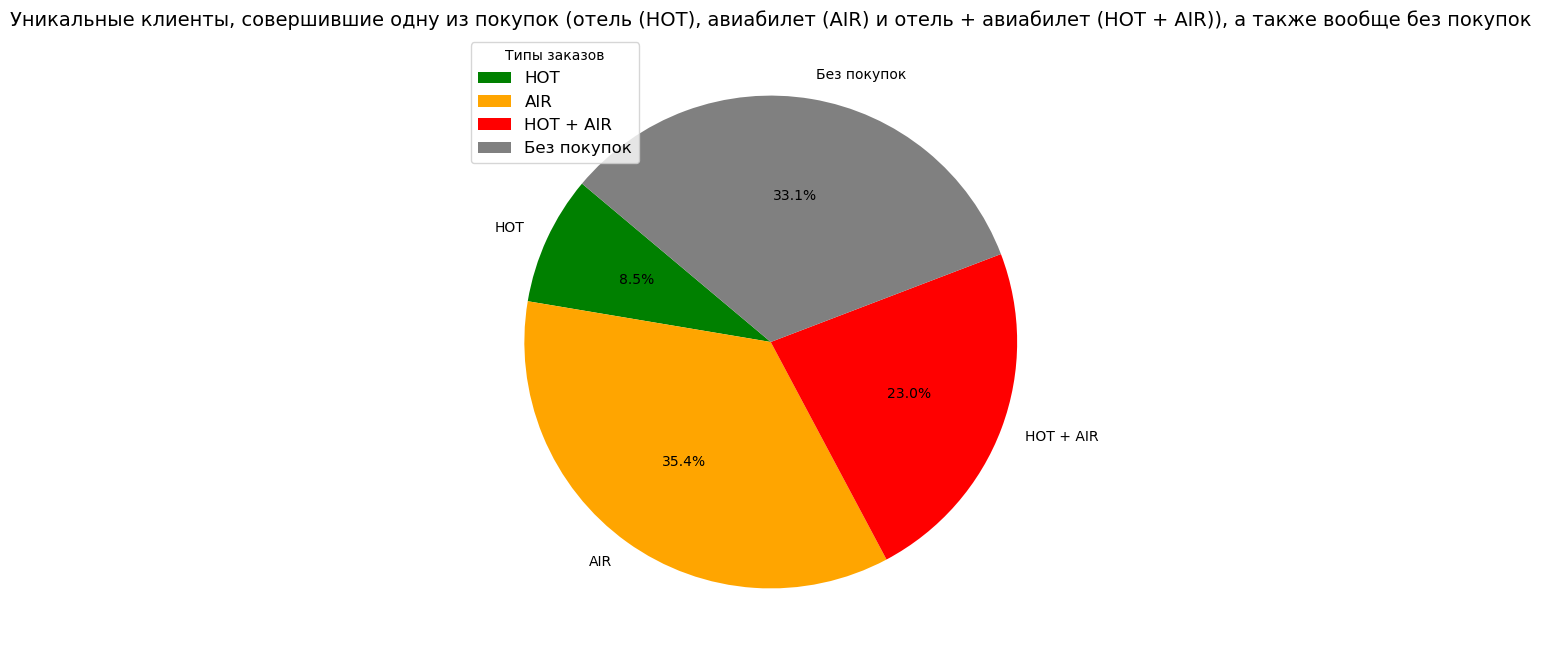

In [59]:
labels = ['HOT', 'AIR', 'HOT + AIR', 'Без покупок']
sizes = [clients_suc_order_type[labels[0]], clients_suc_order_type[labels[1]], clients_suc_order_type[labels[2]], count_NaN_clients]
colors = ['green', 'orange', 'red', 'grey']

plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title('Уникальные клиенты, совершившие одну из покупок (отель (HOT), авиабилет (AIR) и отель + авиабилет (HOT + AIR)), \
а также вообще без покупок', fontsize=14)

plt.legend(labels, title="Типы заказов", loc="best", fontsize=12)
plt.show()

**Итого, около 33% клиентов не совершила ни одной покупки**

# Временная зависимость бронирования отелей по дням

In [181]:
start_date = pd.to_datetime('2024-01-01')
end_date = pd.to_datetime('2024-12-30')

df2_HOT_interval = df2_HOT[(df2_HOT['created_dttm'] >= start_date) & (df2_HOT['created_dttm'] <= end_date)].copy()

df2_HOT_interval['date'] = df2_HOT_interval['created_dttm'].dt.date

counts_of_bookings_hot = df2_HOT_interval.groupby(['date', 'order_status_cd']).size().reset_index(name='count')
counts_of_bookings_hot

,date,order_status_cd,count
0,2024-01-01,SUC,222
1,2024-01-02,SUC,273
2,2024-01-03,SUC,279
3,2024-01-04,SUC,249
4,2024-01-05,SUC,278
...,...,...,...
307,2024-11-03,SUC,433
308,2024-11-04,SUC,387
309,2024-11-05,SUC,510
310,2024-11-06,SUC,488


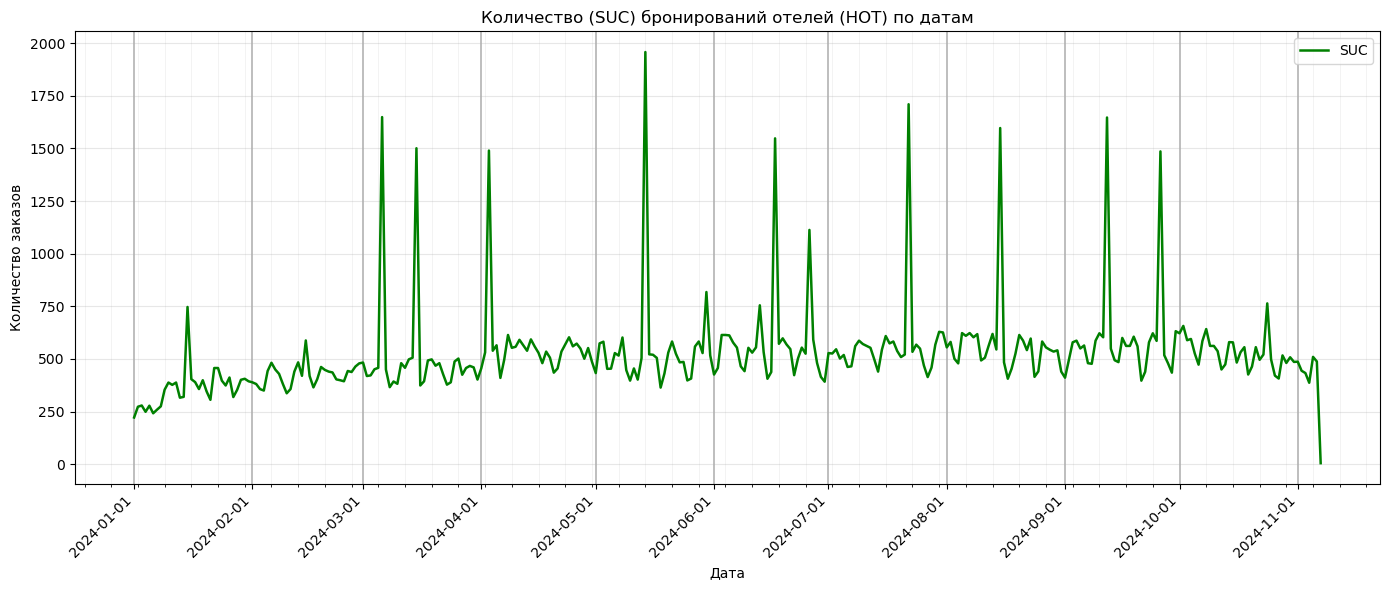

In [182]:
import matplotlib.dates as mdates

subset = counts_of_bookings_hot[counts_of_bookings_hot['order_status_cd'] == 'SUC']

plt.figure(figsize=(14, 6))
plt.plot(subset['date'], subset['count'], label='SUC', linewidth=1.8, color='green')

plt.title('Количество (SUC) бронирований отелей (HOT) по датам')
plt.xlabel('Дата')
plt.ylabel('Количество заказов')

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

plt.gca().xaxis.set_minor_locator(mdates.WeekdayLocator(interval=1))

plt.grid(True, which='major', linewidth=1.2, alpha=0.8, color='black', axis='x')
plt.grid(True, which='minor', linewidth=0.5, alpha=0.2, axis='x')

plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

**Явно наблюдаются резкие большие пики успешных бронирований впоть до нескольких тысяч, а также регулярные более мелкие скачки, которые предположительно возникают каждую неделю.**

# Временная зависимость бронирования отелей по месяцам (исключая ноябрь и декабрь, т.к. неполные)

In [183]:
start_date = pd.to_datetime('2024-01-01')
end_date = pd.to_datetime('2024-10-30')

df2_HOT_interval = df2_HOT[(df2_HOT['created_dttm'] >= start_date) & (df2_HOT['created_dttm'] <= end_date)].copy()

df2_HOT_interval['month'] = df2_HOT_interval['created_dttm'].dt.month
counts_by_month = df2_HOT_interval.groupby(['month', 'order_status_cd']).size().reset_index(name='count')
counts_by_month


,month,order_status_cd,count
0,1,SUC,11139
1,2,SUC,12282
2,3,SUC,16018
3,4,SUC,16928
4,5,SUC,17065
5,6,SUC,17363
6,7,SUC,17724
7,8,SUC,17780
8,9,SUC,18192
9,10,SUC,15555


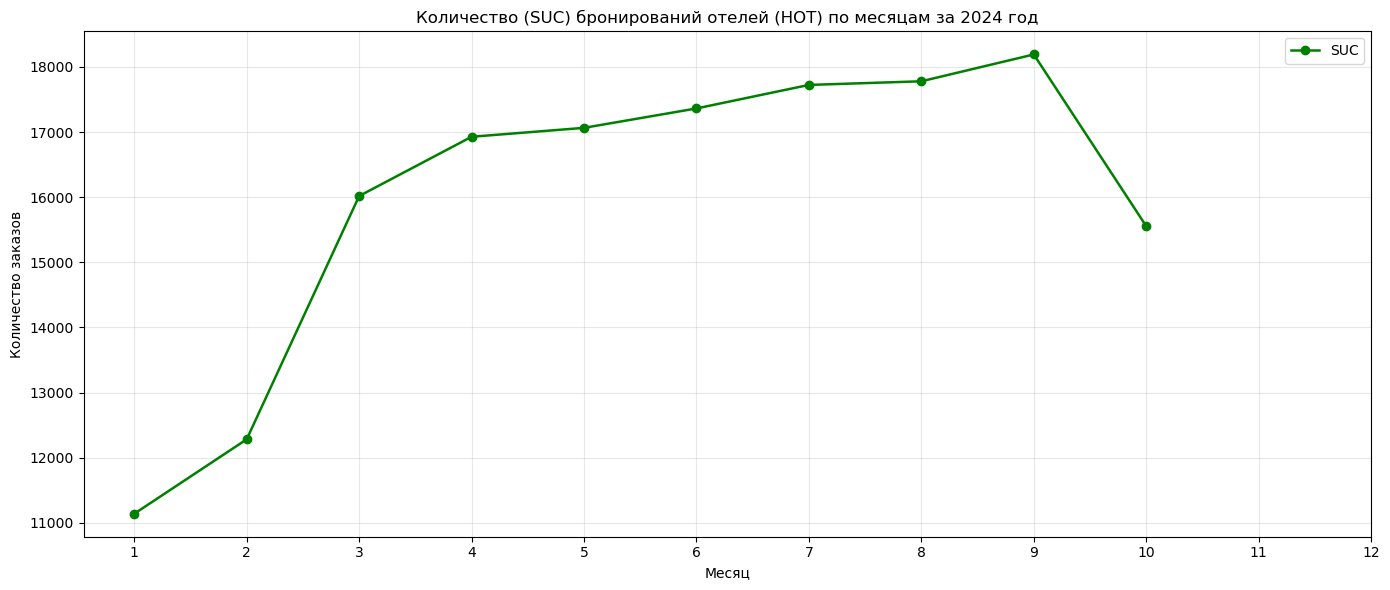

In [184]:
import matplotlib.dates as mdates


subset = counts_by_month[counts_by_month['order_status_cd'] == 'SUC']

plt.figure(figsize=(14, 6))
plt.plot(subset['month'], subset['count'], marker='o', linewidth=1.8, color='green', label='SUC')

plt.title('Количество (SUC) бронирований отелей (HOT) по месяцам за 2024 год')
plt.xlabel('Месяц')
plt.ylabel('Количество заказов')

plt.xticks(range(1, 13))  
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Временная зависимость бронирования авиабилетов по дням

In [185]:
start_date = pd.to_datetime('2024-01-01')
end_date = pd.to_datetime('2024-12-30')

df2_AIR_interval = df2_AIR[(df2_AIR['created_dttm'] >= start_date) & (df2_AIR['created_dttm'] <= end_date)].copy()
df2_AIR_interval['date'] = df2_AIR_interval['created_dttm'].dt.date

counts_of_bookings_air = df2_AIR_interval.groupby(['date', 'order_status_cd']).size().reset_index(name='count')
counts_of_bookings_air

,date,order_status_cd,count
0,2024-01-01,PRC,47
1,2024-01-01,SUC,1111
2,2024-01-02,PRC,45
3,2024-01-02,SUC,1409
4,2024-01-03,PRC,58
...,...,...,...
617,2024-11-04,SUC,1520
618,2024-11-05,PRC,41
619,2024-11-05,SUC,2098
620,2024-11-06,PRC,14


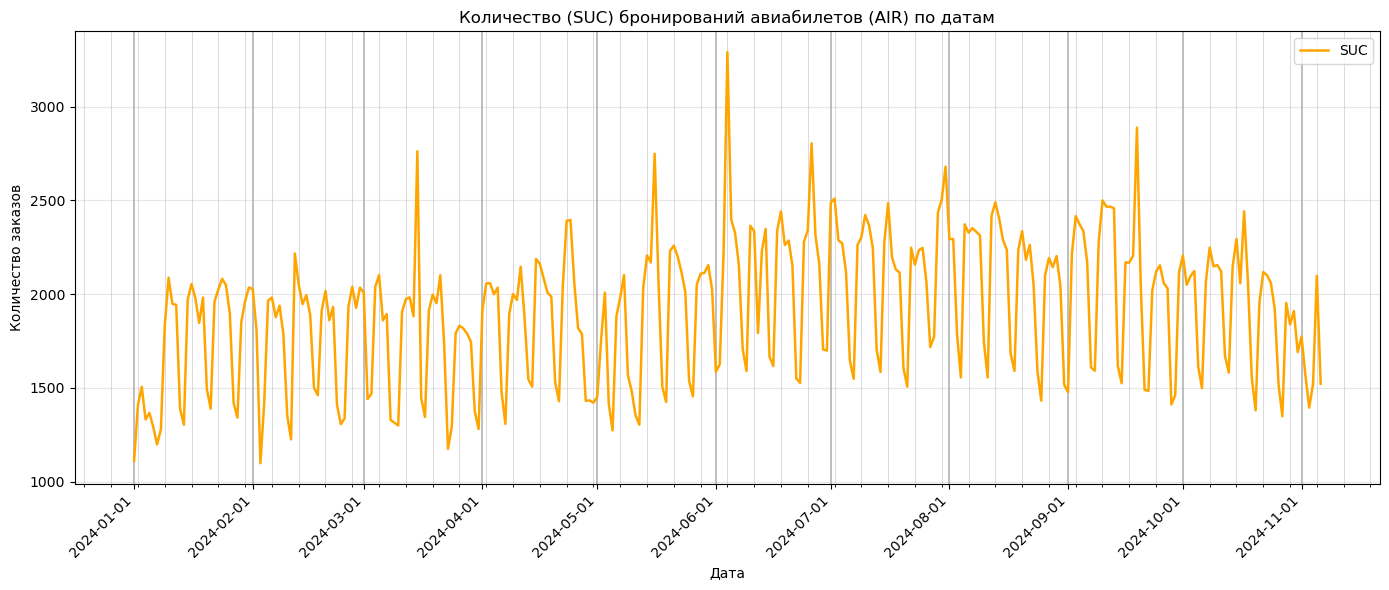

In [186]:
import matplotlib.dates as mdates

subset = counts_of_bookings_air[counts_of_bookings_air['order_status_cd'] == 'SUC']

plt.figure(figsize=(14, 6))
plt.plot(subset['date'], subset['count'], label='SUC', linewidth=1.8, color='orange')

plt.title('Количество (SUC) бронирований авиабилетов (AIR) по датам')
plt.xlabel('Дата')
plt.ylabel('Количество заказов')

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

plt.gca().xaxis.set_minor_locator(mdates.WeekdayLocator(interval=1))

plt.grid(True, which='major', linewidth=1.2, alpha=0.8, color='black', axis='x')
plt.grid(True, which='minor', linewidth=0.5, alpha=0.2, color='black', axis='x')

plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# Временная зависимость бронирования авиабилетов по месяцам (исключая ноябрь и декабрь, т.к. неполные)

In [187]:
start_date = pd.to_datetime('2024-01-01')
end_date = pd.to_datetime('2024-10-30')

df2_AIR_interval = df2_AIR[(df2_AIR['created_dttm'] >= start_date) & (df2_AIR['created_dttm'] <= end_date)].copy()
df2_AIR_interval['month'] = df2_AIR_interval['created_dttm'].dt.month

counts_by_month_air = df2_AIR_interval.groupby(['month', 'order_status_cd']).size().reset_index(name='count')
counts_by_month_air

,month,order_status_cd,count
0,1,PRC,1891
1,1,SUC,52340
2,2,PRC,1672
3,2,SUC,51258
4,3,PRC,1987
5,3,SUC,53856
6,4,PRC,1910
7,4,SUC,55966
8,5,PRC,1834
9,5,SUC,58008


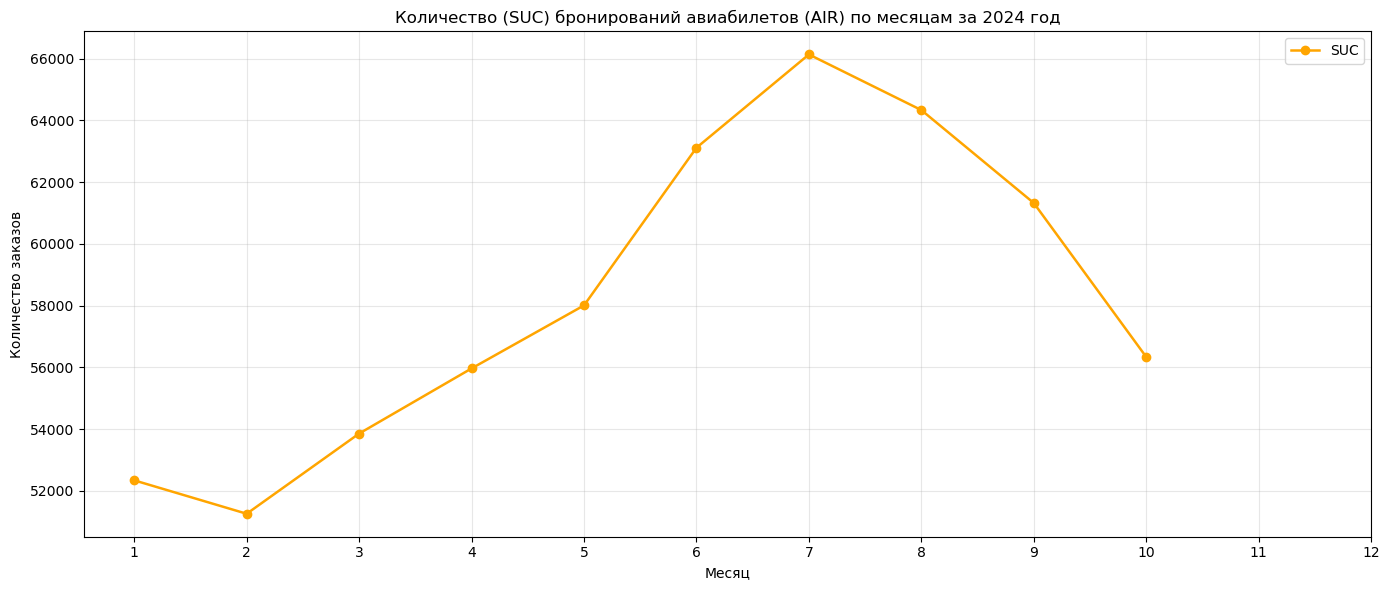

In [188]:
subset = counts_by_month_air[counts_by_month_air['order_status_cd'] == 'SUC']

plt.figure(figsize=(14, 6))
plt.plot(subset['month'], subset['count'], marker='o', linewidth=1.8, color='orange', label='SUC')

plt.title('Количество (SUC) бронирований авиабилетов (AIR) по месяцам за 2024 год')
plt.xlabel('Месяц')
plt.ylabel('Количество заказов')

plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

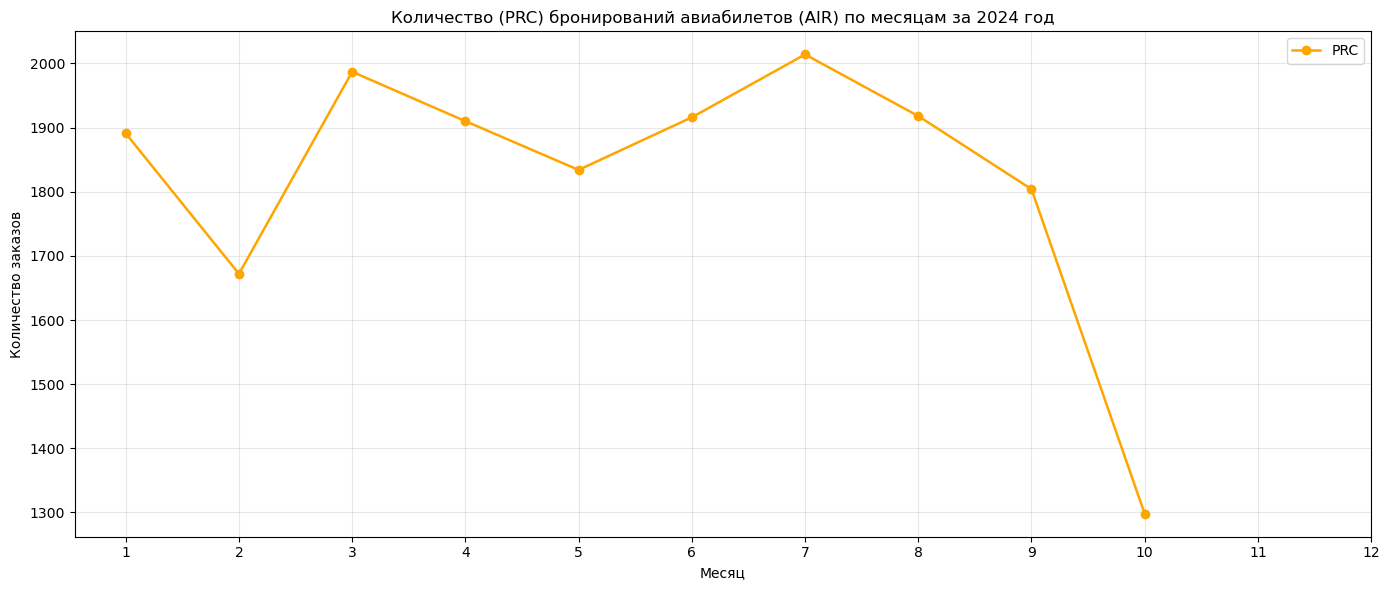

In [189]:
subset = counts_by_month_air[counts_by_month_air['order_status_cd'] == 'PRC']

plt.figure(figsize=(14, 6))
plt.plot(subset['month'], subset['count'], marker='o', linewidth=1.8, color='orange', label='PRC')

plt.title('Количество (PRC) бронирований авиабилетов (AIR) по месяцам за 2024 год')
plt.xlabel('Месяц')
plt.ylabel('Количество заказов')

plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Бронирование авиабилетов и отелей на одном графике

In [216]:
start_date = pd.to_datetime('2024-01-01')
end_date = pd.to_datetime('2024-12-01')

df2_AIR_interval = df2_AIR[(df2_AIR['created_dttm'] >= start_date) & (df2_AIR['created_dttm'] <= end_date)].copy()
df2_AIR_interval['date'] = df2_AIR_interval['created_dttm'].dt.date

df2_HOT_interval = df2_HOT[(df2_HOT['created_dttm'] >= start_date) & (df2_HOT['created_dttm'] <= end_date)].copy()
df2_HOT_interval['date'] = df2_HOT_interval['created_dttm'].dt.date

counts_of_bookings_air = df2_AIR_interval.groupby(['date', 'order_status_cd']).size().reset_index(name='count')
counts_of_bookings_hot = df2_HOT_interval.groupby(['date', 'order_status_cd']).size().reset_index(name='count')
counts_of_bookings_air

,date,order_status_cd,count
0,2024-01-01,PRC,47
1,2024-01-01,SUC,1111
2,2024-01-02,PRC,45
3,2024-01-02,SUC,1409
4,2024-01-03,PRC,58
...,...,...,...
617,2024-11-04,SUC,1520
618,2024-11-05,PRC,41
619,2024-11-05,SUC,2098
620,2024-11-06,PRC,14


In [191]:
counts_of_bookings_hot

,date,order_status_cd,count
0,2024-01-01,SUC,222
1,2024-01-02,SUC,273
2,2024-01-03,SUC,279
3,2024-01-04,SUC,249
4,2024-01-05,SUC,278
...,...,...,...
307,2024-11-03,SUC,433
308,2024-11-04,SUC,387
309,2024-11-05,SUC,510
310,2024-11-06,SUC,488


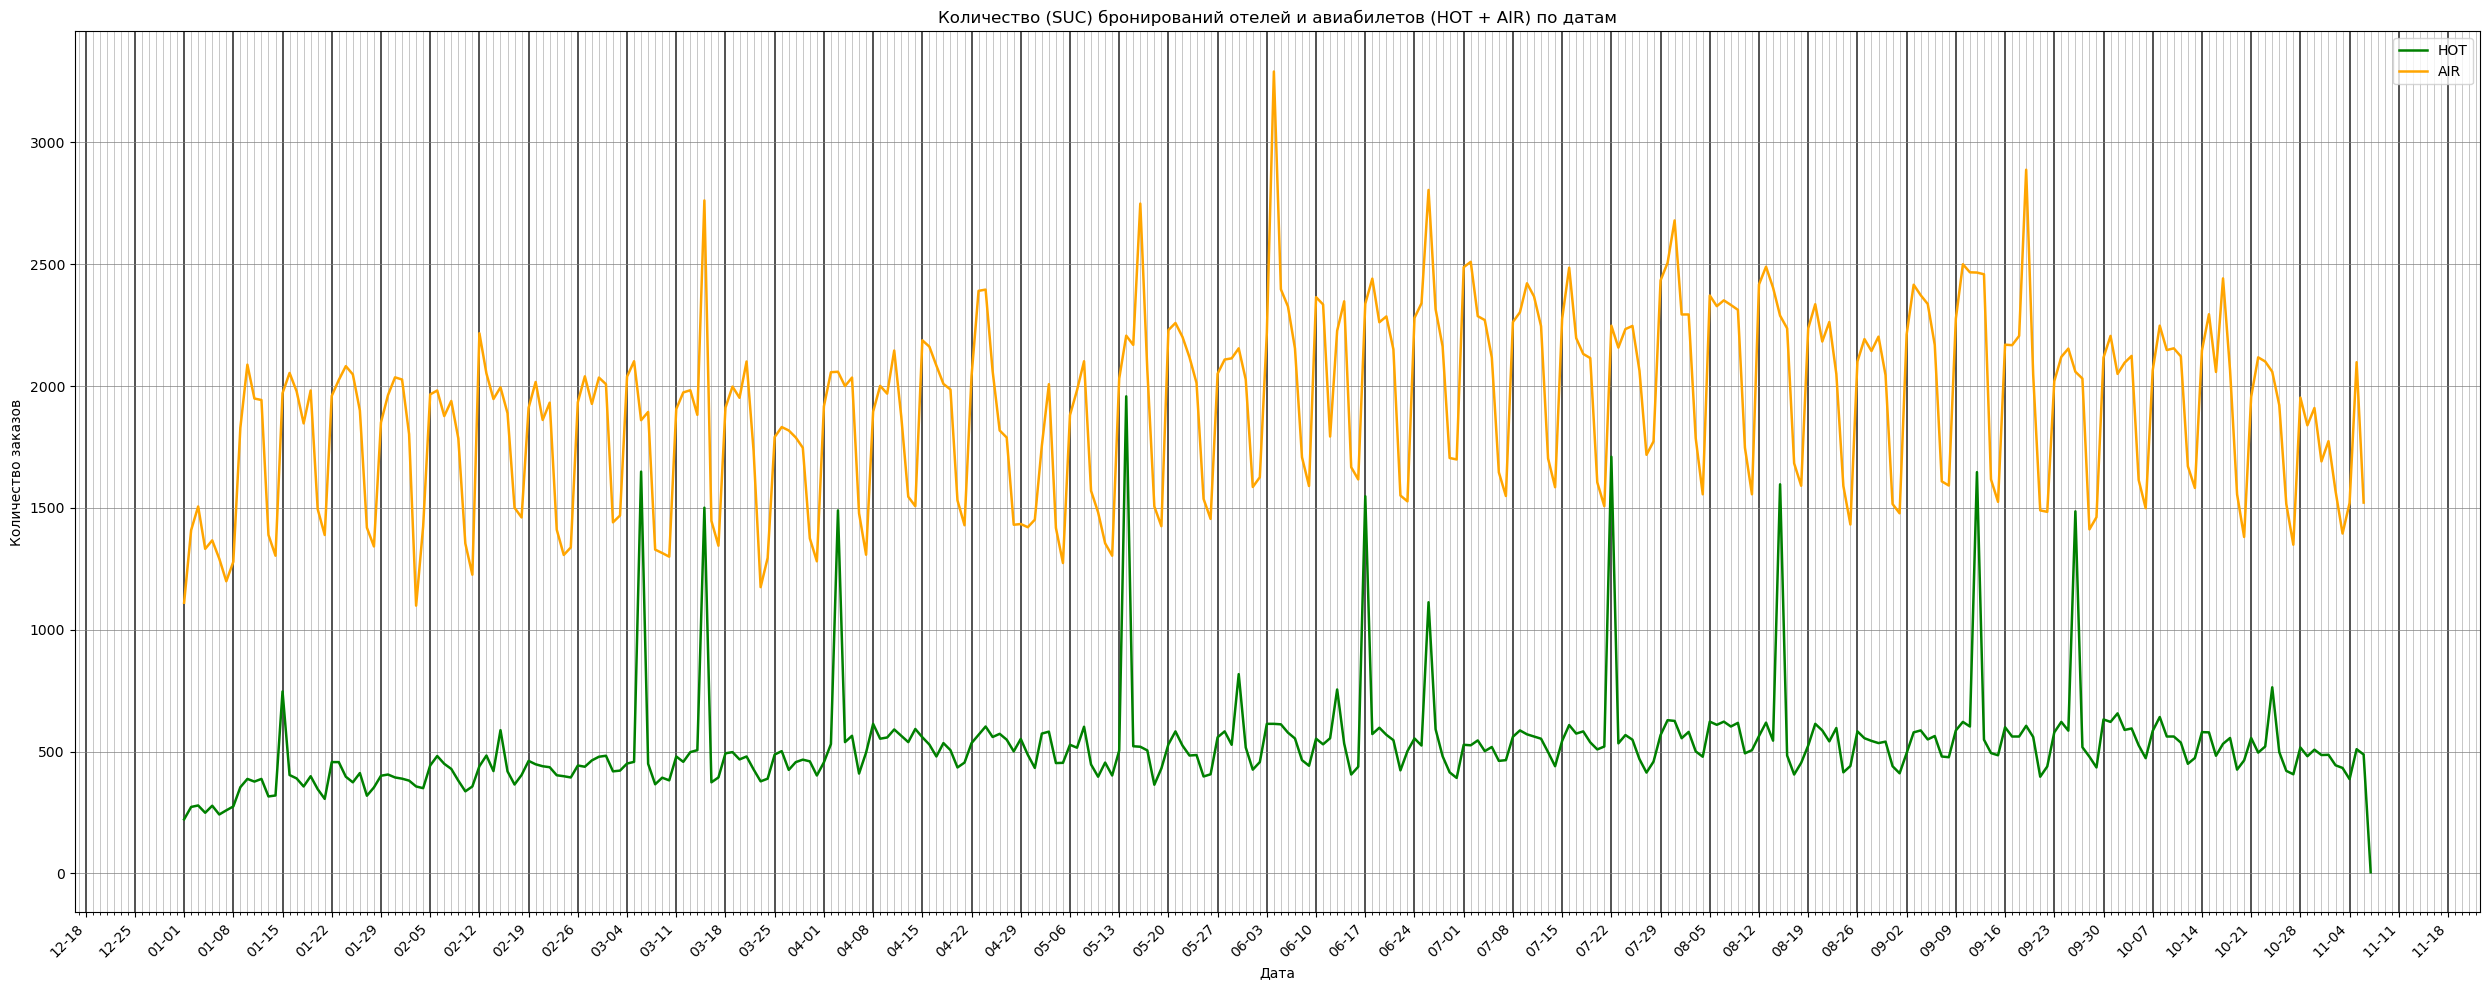

In [217]:
import matplotlib.dates as mdates


plt.figure(figsize=(25, 10))

subset = counts_of_bookings_hot[counts_of_bookings_in_interval['order_status_cd'] == 'SUC']
plt.plot(subset['date'], subset['count'], label='HOT', linewidth=1.8, color='green')

subset = counts_of_bookings_air[counts_of_bookings_air['order_status_cd'] == 'SUC']
plt.plot(subset['date'], subset['count'], label='AIR', linewidth=1.8, color='orange')

plt.title('Количество (SUC) бронирований отелей и авиабилетов (HOT + AIR) по датам')
plt.xlabel('Дата')
plt.ylabel('Количество заказов')

plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(interval=1, byweekday=0))
# plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

plt.gca().xaxis.set_minor_locator(mdates.DayLocator(interval=1))  

plt.grid(True, which='major', linewidth=1.2, alpha=0.8, color='black', axis='x')
# plt.grid(False, which='major', axis='x')
plt.grid(True, which='major', linewidth=0.5, alpha=1, color='grey', axis='y')
plt.grid(True, which='minor', linewidth=0.5, alpha=1)

plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

# Вырезаем данные с явными большими пиками.

**Вырезаем не отдельные дни, а целые недели, содержащие соответствующий пик, чтобы потом собрать более достоверную статистику по неделям**

**Также добавляем столбцы "даты" (без времени) и "дня недели" для удобства дальнейшего использования и создания статистики по дням недели**

In [207]:
df2_HOT['date'] = df2_HOT['created_dttm'].dt.date
df2_HOT['weekday'] = pd.to_datetime(df2_HOT['date']).dt.day_name()

In [208]:
df2_AIR['date'] = df2_AIR['created_dttm'].dt.date
df2_AIR['weekday'] = pd.to_datetime(df2_AIR['date']).dt.day_name()

In [195]:
intervals = [
    ('2024-01-15', '2024-01-21'),
    ('2024-03-04', '2024-03-17'),  
    ('2024-04-01', '2024-04-07'),
    ('2024-05-13', '2024-05-19'),
    ('2024-06-17', '2024-06-30'), 
    ('2024-07-22', '2024-07-28'),
    ('2024-08-12', '2024-08-18'),
    ('2024-09-09', '2024-09-15'),
    ('2024-09-23', '2024-09-29'),
]

In [196]:
pd.to_datetime('2024-03-04').day_name()

'Monday'

In [218]:
df2_HOT_interval = df2_HOT.copy()
for s, e in intervals:
    s_d = pd.to_datetime(s).date()
    e_d = pd.to_datetime(e).date()
    df2_HOT_interval = df2_HOT_interval[~((df2_HOT_interval['date'] >= s_d) & (df2_HOT_interval['date'] <= e_d))]

df2_AIR_interval = df2_AIR.copy()
for s, e in intervals:
    s_d = pd.to_datetime(s).date()
    e_d = pd.to_datetime(e).date()
    df2_AIR_interval = df2_AIR_interval[~((df2_AIR_interval['date'] >= s_d) & (df2_AIR_interval['date'] <= e_d))]

In [219]:
counts_of_bookings_air = df2_AIR_interval.groupby(['date', 'order_status_cd']).size().reset_index(name='count')
counts_of_bookings_hot = df2_HOT_interval.groupby(['date', 'order_status_cd']).size().reset_index(name='count')
counts_of_bookings_hot

,date,order_status_cd,count
0,2024-01-01,SUC,222
1,2024-01-02,SUC,273
2,2024-01-03,SUC,279
3,2024-01-04,SUC,249
4,2024-01-05,SUC,278
...,...,...,...
230,2024-11-03,SUC,433
231,2024-11-04,SUC,387
232,2024-11-05,SUC,510
233,2024-11-06,SUC,488


In [213]:
counts_of_bookings_air

,date,order_status_cd,count
0,2024-01-01,PRC,47
1,2024-01-01,SUC,1111
2,2024-01-02,PRC,45
3,2024-01-02,SUC,1409
4,2024-01-03,PRC,58
...,...,...,...
463,2024-11-04,SUC,1520
464,2024-11-05,PRC,41
465,2024-11-05,SUC,2098
466,2024-11-06,PRC,14


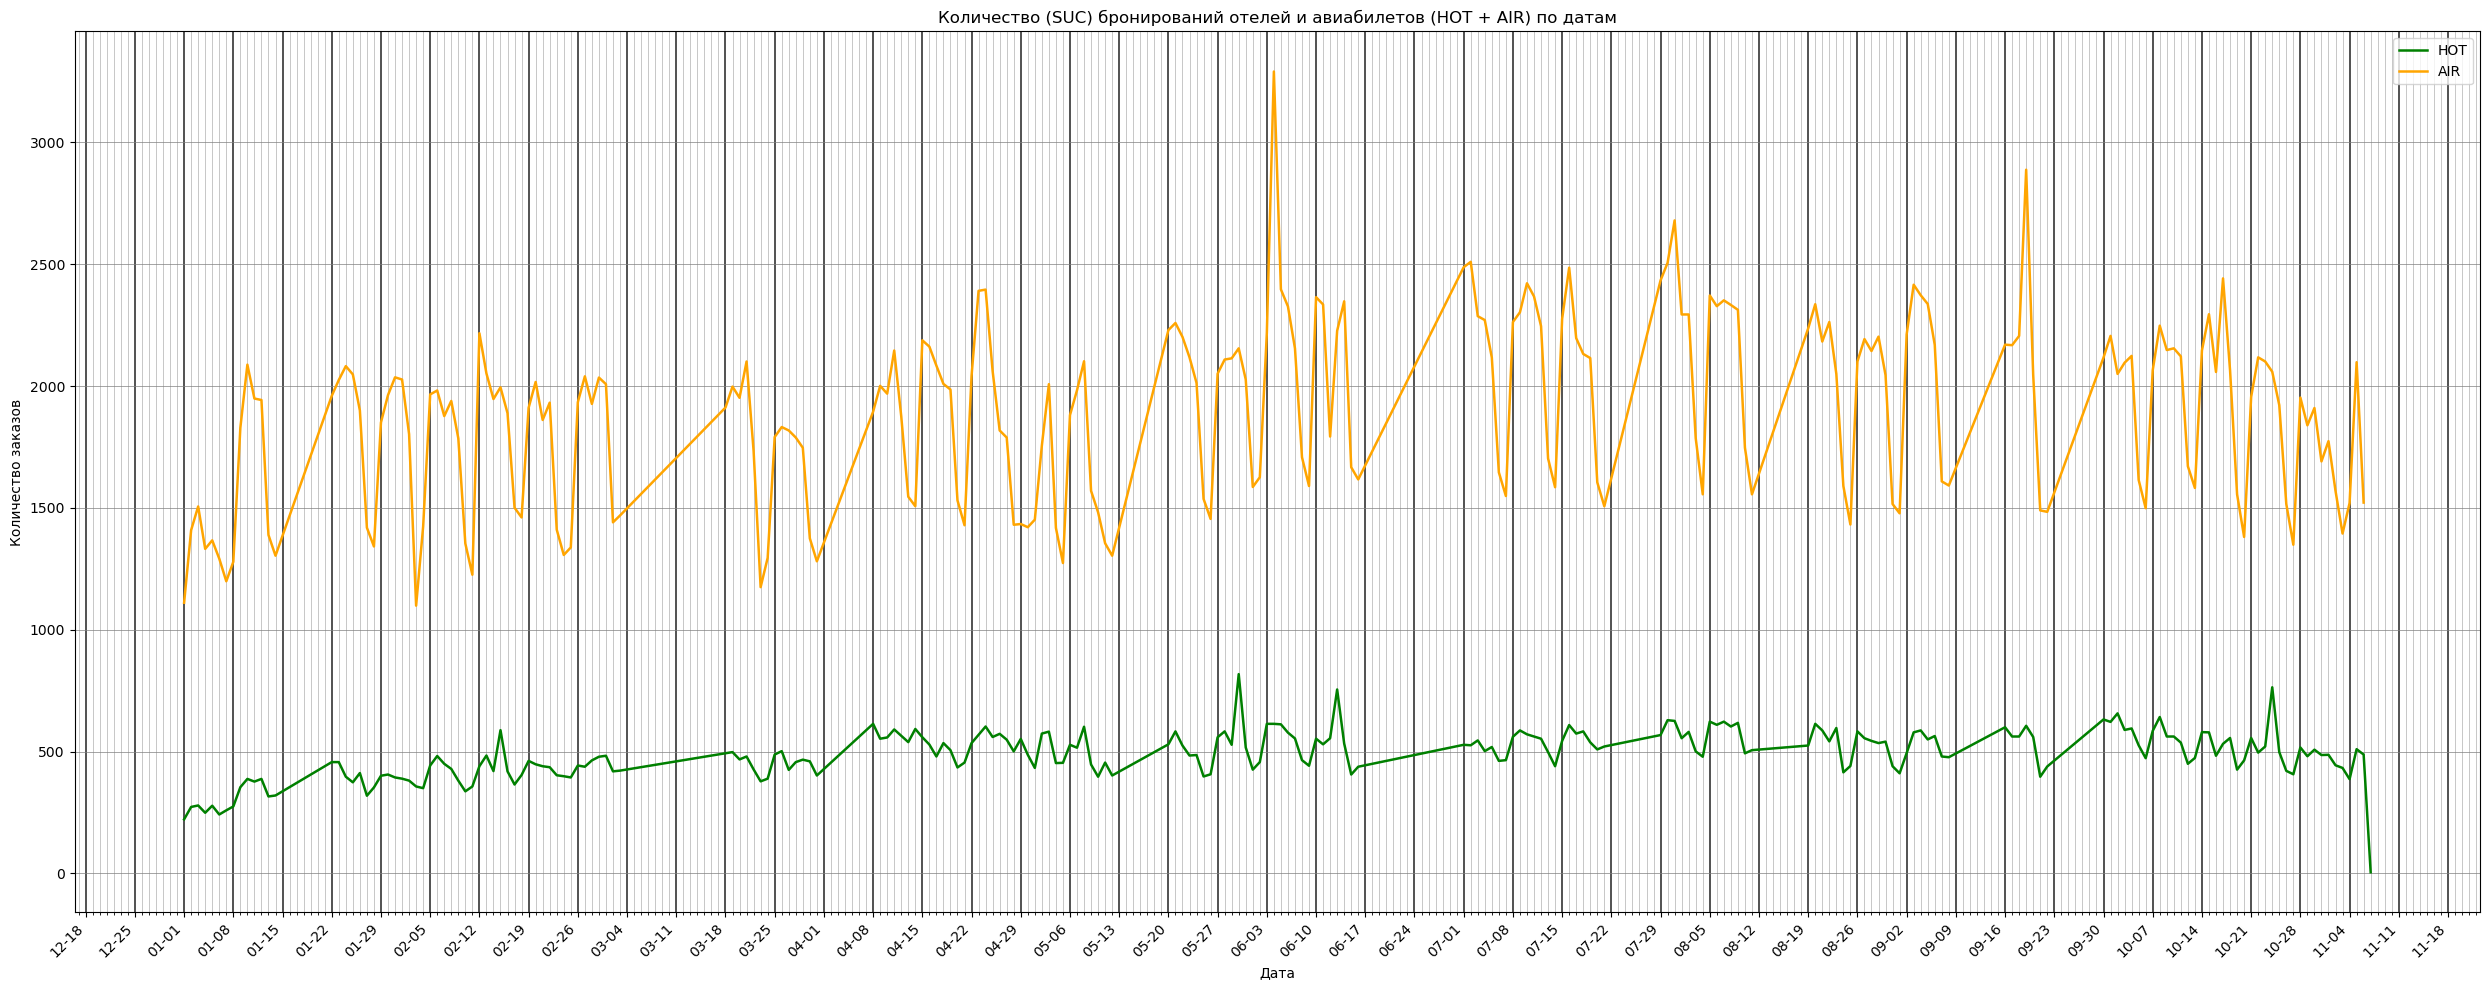

In [220]:
import matplotlib.dates as mdates


plt.figure(figsize=(25, 10))

subset = counts_of_bookings_hot[counts_of_bookings_hot['order_status_cd'] == 'SUC']
plt.plot(subset['date'], subset['count'], label='HOT', linewidth=1.8, color='green')

subset = counts_of_bookings_air[counts_of_bookings_air['order_status_cd'] == 'SUC']
plt.plot(subset['date'], subset['count'], label='AIR', linewidth=1.8, color='orange')

plt.title('Количество (SUC) бронирований отелей и авиабилетов (HOT + AIR) по датам')
plt.xlabel('Дата')
plt.ylabel('Количество заказов')

plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator(interval=1, byweekday=0))
# plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))

plt.gca().xaxis.set_minor_locator(mdates.DayLocator(interval=1))  

plt.grid(True, which='major', linewidth=1.2, alpha=0.8, color='black', axis='x')
# plt.grid(False, which='major', axis='x')
plt.grid(True, which='major', linewidth=0.5, alpha=1, color='grey', axis='y')
plt.grid(True, which='minor', linewidth=0.5, alpha=1)

plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

# Статистика заказов по дням недели (без учёта пиковых значений в отдельные дни)

In [221]:
counts_of_bookings_day_air = df2_AIR_interval.groupby(['weekday', 'order_status_cd']).size().reset_index(name='count')
counts_of_bookings_day_hot = df2_HOT_interval.groupby(['weekday', 'order_status_cd']).size().reset_index(name='count')

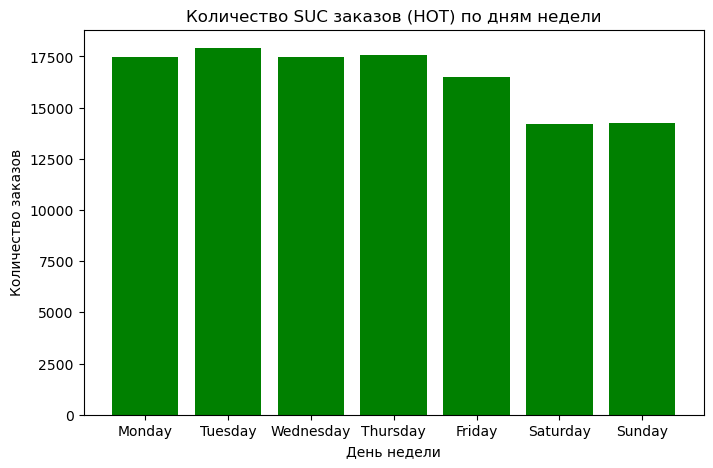

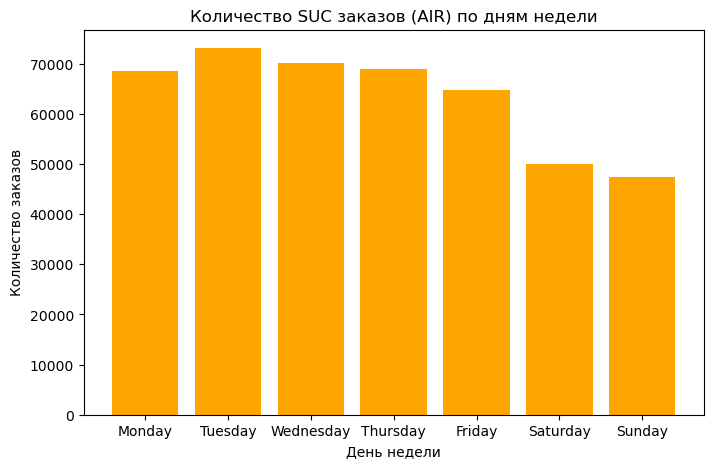

In [222]:
week_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']


subset_hot = counts_of_bookings_day_hot[counts_of_bookings_day_hot['order_status_cd'] == 'SUC'].copy()
subset_hot['weekday'] = pd.Categorical(subset_hot['weekday'], categories=week_order, ordered=True)
subset_hot = subset_hot.sort_values('weekday')

plt.figure(figsize=(8, 5))
plt.bar(subset_hot['weekday'], subset_hot['count'], color='green')
plt.title('Количество SUC заказов (HOT) по дням недели')
plt.xlabel('День недели')
plt.ylabel('Количество заказов')
plt.show()


subset_air = counts_of_bookings_day_air[counts_of_bookings_day_air['order_status_cd'] == 'SUC'].copy()
subset_air['weekday'] = pd.Categorical(subset_air['weekday'], categories=week_order, ordered=True)
subset_air = subset_air.sort_values('weekday')

plt.figure(figsize=(8, 5))
plt.bar(subset_air['weekday'], subset_air['count'], color='orange')
plt.title('Количество SUC заказов (AIR) по дням недели')
plt.xlabel('День недели')
plt.ylabel('Количество заказов')
plt.show()

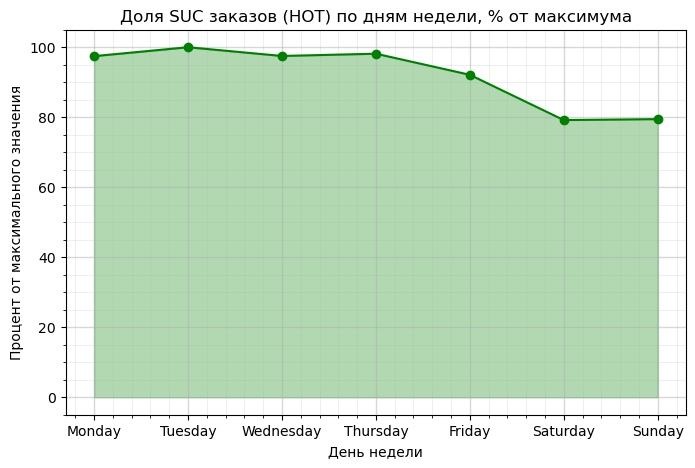

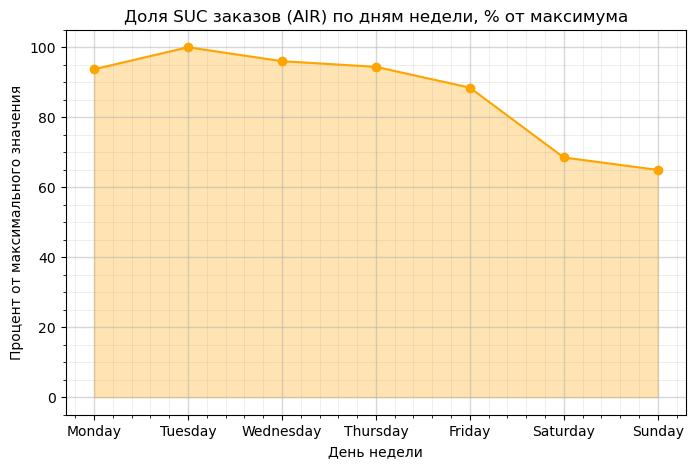

In [234]:
subset_hot['percent'] = subset_hot['count'] / subset_hot['count'].max() * 100

plt.figure(figsize=(8, 5))
plt.plot(subset_hot['weekday'], subset_hot['percent'], color='green', marker='o')
plt.fill_between(subset_hot['weekday'], subset_hot['percent'], color='green', alpha=0.3)
plt.grid(True, alpha=0.3)
plt.title('Доля SUC заказов (HOT) по дням недели, % от максимума')
plt.xlabel('День недели')
plt.ylabel('Процент от максимального значения')
plt.minorticks_on()
plt.grid(True, which='major', linewidth=1, alpha=0.5)
plt.grid(True, which='minor', linewidth=0.5, alpha=0.3)
plt.show()


subset_air['percent'] = subset_air['count'] / subset_air['count'].max() * 100

plt.figure(figsize=(8, 5))
plt.plot(subset_air['weekday'], subset_air['percent'], color='orange', marker='o')
plt.fill_between(subset_air['weekday'], subset_air['percent'], color='orange', alpha=0.3)
plt.grid(True, alpha=0.3)
plt.title('Доля SUC заказов (AIR) по дням недели, % от максимума')
plt.xlabel('День недели')
plt.ylabel('Процент от максимального значения')
plt.minorticks_on()
plt.grid(True, which='major', linewidth=1, alpha=0.5)
plt.grid(True, which='minor', linewidth=0.5, alpha=0.3)
plt.show()

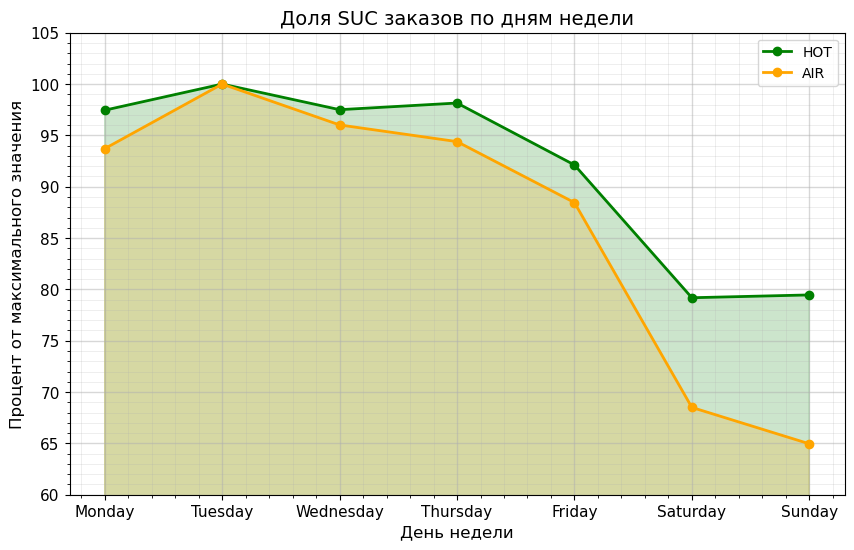

In [233]:
plt.figure(figsize=(10, 6))

plt.plot(subset_hot['weekday'], subset_hot['percent'], color='green', linewidth=2, marker='o', label='HOT')
plt.fill_between(subset_hot['weekday'], subset_hot['percent'], color='green', alpha=0.2)

plt.plot(subset_air['weekday'], subset_air['percent'], color='orange', linewidth=2, marker='o', label='AIR')
plt.fill_between(subset_air['weekday'], subset_air['percent'], color='orange', alpha=0.2)

plt.ylim(60, 105)
plt.xlabel('День недели', fontsize=12)
plt.ylabel('Процент от максимального значения', fontsize=12)
plt.title('Доля SUC заказов по дням недели', fontsize=14)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.legend()
plt.minorticks_on()
plt.grid(True, which='major', linewidth=1, alpha=0.5)
plt.grid(True, which='minor', linewidth=0.5, alpha=0.3)
plt.show()